<a href="https://colab.research.google.com/github/AdwaaNasser/DataMiningProject/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Quality and Pollution Assessment


## 1. Problem

Air pollution is one of the most critical environmental problems affecting public health and quality of life.  
Exposure to high levels of pollutants such as **PM2.5, PM10, NO₂, SO₂, and CO** increases the risk of respiratory diseases, heart problems, and other long‑term complications.

However, it is not always easy to understand how different environmental factors (temperature, humidity, population density, proximity to industrial areas, etc.) interact and contribute to air quality. Raw measurements alone are difficult to interpret, and it is hard to identify when air quality becomes dangerous without proper analysis.

In this project, our goal is to **analyze air quality data and prepare it for data mining techniques**. The cleaned and transformed dataset will later be used to:

- Study how different pollutants and environmental variables are related.
- Compare air quality across different locations or conditions.
- Build models that can classify or group air quality levels to support decision‑making and early warnings.

This phase focuses on summarizing the data and applying preprocessing so that the next phases (classification and clustering) are based on reliable and well‑prepared data.

## 2. Data Mining Task

The air quality problem in this project can be viewed as both a **classification** and a **clustering** task.

###Classification

- **Type:** Supervised learning  
- **Class attribute:** `Air Quality`  
- **Goal:** Predict the air quality category (e.g., *Good*, *Moderate*, *Poor*, *Hazardous*) using pollutant and environmental attributes.  
- **Input features include:**
  - `Temperature`
  - `Humidity`
  - `PM2.5`
  - `PM10`
  - `NO2`
  - `SO2`
  - `CO`
  - `Proximity_to_Industrial_Areas`
  - `Population_Density`

A classification model will allow us later to estimate the air quality level for new observations. This can support early warnings and help authorities focus on areas with potentially harmful conditions.

###Clustering

- **Type:** Unsupervised learning  
- **Goal:** Group records into clusters based **only** on the similarity of their feature values, without using the `Air Quality` label during training.

By applying clustering, we can:

- Discover natural groups of locations with similar pollution patterns.  
- Identify clusters representing highly polluted areas versus relatively clean ones.  
- Explore hidden structures that may not be obvious from simple visual inspection.

In summary, **classification** will be used later to predict a known label, while **clustering** is used to explore hidden structure in the data. Both tasks depend on the same cleaned and preprocessed dataset prepared in this phase.


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns


## 3. Data

In this section, we describe the air quality dataset used in the project and provide a basic summary of its attributes.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the original air quality dataset (same source used in Phase 2)
df = pd.read_csv("https://raw.githubusercontent.com/AdwaaNasser/DataMiningProject/main/Dataset/Raw_dataset.csv")

print("Number of attributes:", len(df.columns))
print("Number of records:", len(df))
df.head()

Number of attributes: 10
Number of records: 5000


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [ ]:
# Attribute names and data types
attribute_info = pd.DataFrame({
    "Attribute Name": df.columns,
    "Data Type": df.dtypes.astype(str)
})
attribute_info

,Attribute Name,Data Type
Temperature,Temperature,float64
Humidity,Humidity,float64
PM2.5,PM2.5,float64
PM10,PM10,float64
NO2,NO2,float64
SO2,SO2,float64
CO,CO,float64
Proximity_to_Industrial_Areas,Proximity_to_Industrial_Areas,float64
Population_Density,Population_Density,int64
Air Quality,Air Quality,object


### 3.1 Attribute Description

The main attributes in the dataset are:

- **Temperature** (numeric): Ambient temperature in °C.  
- **Humidity** (numeric): Relative humidity percentage.  
- **PM2.5** (numeric): Fine particulate matter concentration.  
- **PM10** (numeric): Coarse particulate matter concentration.  
- **NO2** (numeric): Nitrogen dioxide concentration.  
- **SO2** (numeric): Sulfur dioxide concentration.  
- **CO** (numeric): Carbon monoxide concentration.  
- **Proximity_to_Industrial_Areas** (numeric): Distance or closeness to industrial zones.  
- **Population_Density** (numeric): Number of people per area unit.  
- **Air Quality** (categorical): Overall air quality category (e.g., *Good*, *Moderate*, *Poor*, *Hazardous*).

The dataset mainly consists of numeric pollutant and weather measurements plus one class label representing the air quality level.

### 3.2 Five‑Number Summary

We computed the five‑number summary (minimum, first quartile Q1, median, third quartile Q3, and maximum) for the main numeric attributes to understand their distributions.


In [ ]:
numeric_cols = ['Temperature','Humidity','PM2.5','PM10','NO2','SO2','CO',
                'Proximity_to_Industrial_Areas','Population_Density']

summary = df.describe()[numeric_cols].T
five_number_summary = summary[['min', '25%', '50%', '75%', 'max']]
five_number_summary

,min,25%,50%,75%,max
Temperature,13.40,25.10,29.00,34.000,58.60
Humidity,36.00,58.30,69.80,80.300,128.10
PM2.5,0.00,4.60,12.00,26.100,295.00
PM10,-0.20,12.30,21.70,38.100,315.80
NO2,7.40,20.10,25.30,31.900,64.90
SO2,-6.20,5.10,8.00,13.725,44.90
CO,0.65,1.03,1.41,1.840,3.72
Proximity_to_Industrial_Areas,2.50,5.40,7.90,11.100,25.80
Population_Density,188.00,381.00,494.00,600.000,957.00


**Interpretation of Five‑Number Summary:**  

- **Temperature** ranges from relatively mild to very hot values, with a median around the upper twenties, which suggests generally warm conditions.  
- **Humidity** values are mostly in the moderate to high range, indicating that many observations come from humid environments.  
- **PM2.5 and PM10** show relatively low median values but very high maximum values, which means that there are occasional severe pollution events.  
- **NO2, SO2, and CO** usually remain at moderate levels but also contain some extreme values, especially in highly polluted areas.  
- **Proximity_to_Industrial_Areas** varies across locations, while **Population_Density** shows that some areas are much more crowded than others.

These observations confirm that the dataset contains both typical conditions and some strong outliers, especially for pollutant attributes.

In [ ]:
variance = df[numeric_cols].var(numeric_only=True)
variance

,0
Temperature,45.167289
Humidity,251.653065
PM2.5,602.925723
PM10,747.978707
NO2,79.127365
SO2,45.566596
CO,0.298145
Proximity_to_Industrial_Areas,13.038915
Population_Density,23333.810156


The variance values show which attributes change a lot between observations:

- High variance in **PM2.5, PM10, SO2** indicates that pollution levels can fluctuate strongly over time or between locations.  
- **Temperature** and **Humidity** also vary but within a more limited range.  
- **Proximity_to_Industrial_Areas** and **Population_Density** capture structural differences between regions (urban vs. rural).

Knowing which attributes are highly variable helps in understanding which features may have stronger influence on air quality.


### 3.4 Class Label Distribution and Visualizations

We now inspect how many records fall into each air quality category and visualize some basic patterns.


/tmp/ipython-input-410848279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Air Quality', data=df, palette='pastel', edgecolor='black')


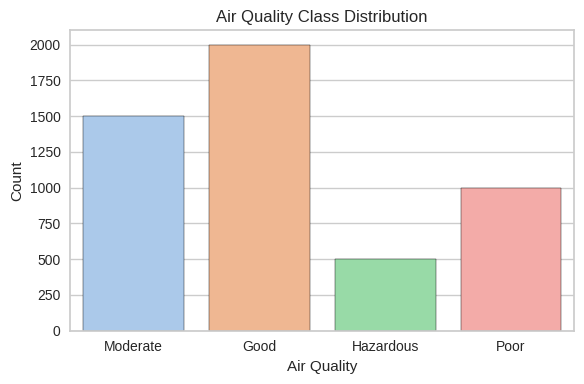

,count
Air Quality,
Good,2000
Moderate,1500
Poor,1000
Hazardous,500


In [ ]:
# Distribution of the class label (Air Quality)
plt.figure(figsize=(6,4))
sns.countplot(x='Air Quality', data=df, palette='pastel', edgecolor='black')
plt.title('Air Quality Class Distribution')
plt.xlabel('Air Quality')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

df['Air Quality'].value_counts()

/tmp/ipython-input-410848279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Air Quality', data=df, palette='pastel', edgecolor='black')


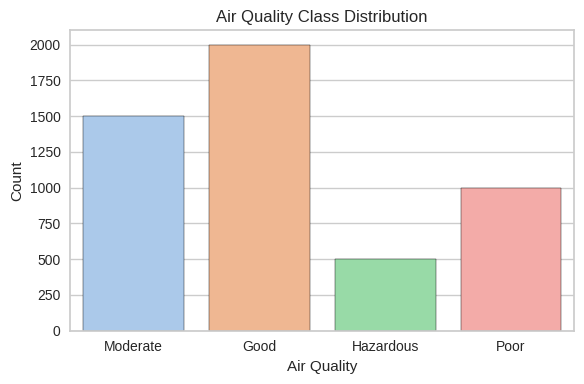

,count
Air Quality,
Good,2000
Moderate,1500
Poor,1000
Hazardous,500


In [ ]:
# Distribution of the class label (Air Quality)
plt.figure(figsize=(6,4))
sns.countplot(x='Air Quality', data=df, palette='pastel', edgecolor='black')
plt.title('Air Quality Class Distribution')
plt.xlabel('Air Quality')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

df['Air Quality'].value_counts()

The class label distribution shows that most records belong to **Good** and **Moderate** air quality, while **Poor** and **Hazardous** conditions are less frequent.  
This means the dataset is slightly imbalanced, which should be considered later when building classification models.


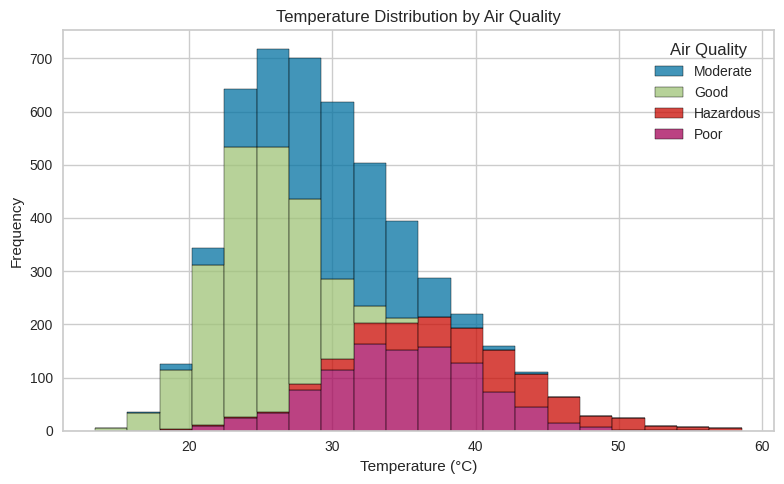

In [ ]:
# Example: histogram of Temperature by Air Quality
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Temperature', hue='Air Quality',
             multiple='stack', bins=20, edgecolor='black')
plt.title('Temperature Distribution by Air Quality')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

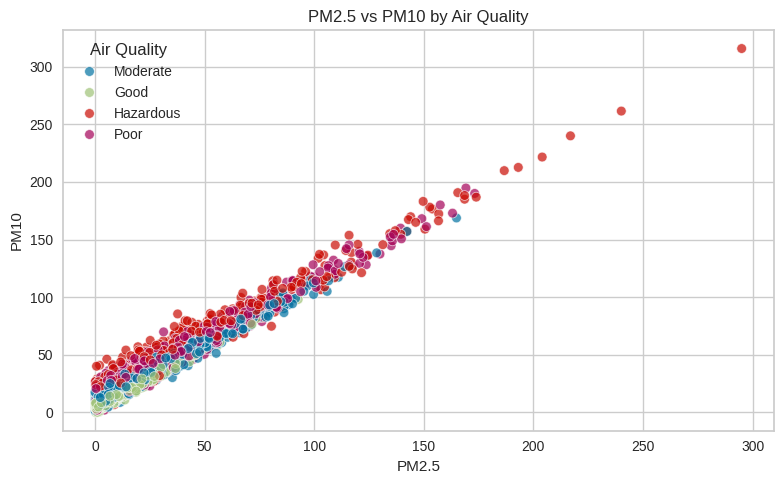

In [ ]:
# Example: scatter plot of PM2.5 vs PM10 colored by Air Quality
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='PM2.5', y='PM10', hue='Air Quality', alpha=0.7)
plt.title('PM2.5 vs PM10 by Air Quality')
plt.xlabel('PM2.5')
plt.ylabel('PM10')
plt.tight_layout()
plt.show()

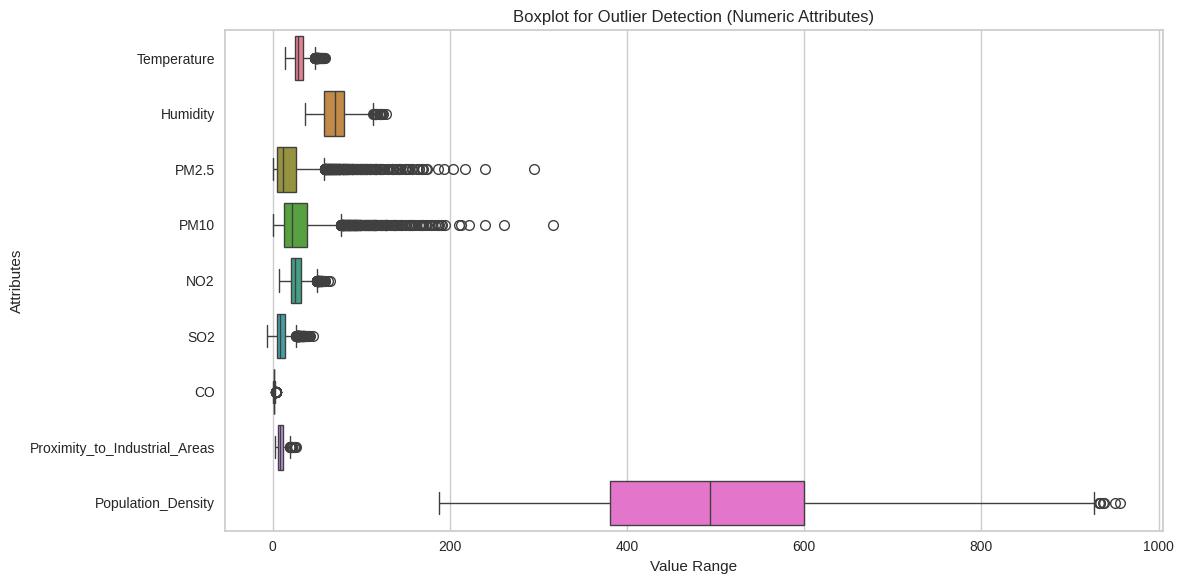

In [ ]:
# Boxplot for outlier inspection (all numeric columns)
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols], orient='h')
plt.title('Boxplot for Outlier Detection (Numeric Attributes)')
plt.xlabel('Value Range')
plt.ylabel('Attributes')
plt.tight_layout()
plt.show()

The plots above give a visual summary of the data:

- The **histogram** shows how temperature values are distributed across different air quality levels.  
- The **scatter plot** reveals the relationship between **PM2.5** and **PM10** and how it relates to the air quality classes.  
- The **boxplot** highlights the presence of outliers, especially in pollutant variables such as PM2.5 and PM10.


## 4. Data Pre‑processing

In this section, we summarize the preprocessing techniques applied to the air quality dataset in order to improve its quality and prepare it for later modeling.

### 4.1 Checking and Handling Missing Values

In [ ]:
# Check for missing values in each column
missing_count = df.isnull().sum()
missing_count

,0
Temperature,0
Humidity,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
Proximity_to_Industrial_Areas,0
Population_Density,0
Air Quality,0


The results show **no missing values** in any attribute.  
Therefore, we did not need to apply imputation or remove any rows, and we were able to keep the full dataset intact.


### 4.2 Detecting and Removing Outliers (IQR Method)

In [ ]:
# Interquartile Range (IQR) method to count outliers
numeric_df = df[numeric_cols]

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers_bool = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
outlier_counts = outliers_bool.sum()
outlier_counts

,0
Temperature,72
Humidity,19
PM2.5,352
PM10,324
NO2,73
SO2,124
CO,45
Proximity_to_Industrial_Areas,16
Population_Density,7


We observe that attributes such as **PM2.5**, **PM10**, and **SO2** contain a relatively large number of outliers.  
These extreme values can distort statistical summaries and may negatively affect some models, so we applied an outlier removal step using the IQR rule.


In [ ]:
# Function to remove outliers using IQR for a single column
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    cleaned = data[(data[column] >= lower) & (data[column] <= upper)]
    return cleaned

# Apply outlier removal
df_cleaned = df.copy()
for col in numeric_cols:
    df_cleaned = remove_outliers_iqr(df_cleaned, col)

print('Shape before outlier removal:', df.shape)
print('Shape after outlier removal :', df_cleaned.shape)

Shape before outlier removal: (5000, 10)
Shape after outlier removal : (4158, 10)


After removing outliers, the dataset becomes more stable and less influenced by extreme measurements.  
This helps the later analysis and data mining models to focus on typical pollution patterns rather than rare extreme cases.


### 4.3 Normalization (Min–Max Scaling)

In [ ]:
from copy import deepcopy

df_normalized = deepcopy(df_cleaned)

num_cols_all = df_normalized.select_dtypes(include='number').columns.tolist()

# If the class label is numeric we would exclude it here. For this dataset, Air Quality is categorical.
cols_to_scale = num_cols_all

df_normalized[cols_to_scale] = (
    (df_normalized[cols_to_scale] - df_normalized[cols_to_scale].min()) /
    (df_normalized[cols_to_scale].max() - df_normalized[cols_to_scale].min())
)

df_normalized[cols_to_scale].describe().T[['min','max']]

,min,max
Temperature,0.0,1.0
Humidity,0.0,1.0
PM2.5,0.0,1.0
PM10,0.0,1.0
NO2,0.0,1.0
SO2,0.0,1.0
CO,0.0,1.0
Proximity_to_Industrial_Areas,0.0,1.0
Population_Density,0.0,1.0


The table confirms that all numeric attributes used for modeling are now scaled between **0** and **1**.  
This step ensures that variables with originally large scales (such as population density) do not dominate those with smaller scales when distance‑based algorithms are applied.


### 4.4 Discretization of Selected Attributes

In [ ]:
# Discretize selected numeric columns into 3 bins (0 = low, 1 = medium, 2 = high)
columns_to_discretize = ['Temperature','Humidity','PM2.5','PM10','NO2','SO2','CO','Proximity_to_Industrial_Areas','Population_Density']
num_bins = 3
bin_edges_dict = {}
df_discretized = df_normalized.copy()
for column in columns_to_discretize: df_discretized[column], bin_edges = pd.cut(df_discretized[column],bins=num_bins,labels=False,retbins=True)
bin_edges_dict[column] = bin_edges

# Show first rows after discretization
df_discretized[columns_to_discretize].head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
0,1,0,0,0,0,1,1,0,0
1,1,1,0,0,1,1,1,0,1
2,0,1,1,1,1,1,1,0,1
3,1,0,0,0,0,1,0,1,1
4,1,1,0,0,1,1,0,1,0


After discretization, each selected attribute is represented by integer values (**0**, **1**, **2**),  
which correspond to automatically computed ranges (low, medium, high).  
This transformation simplifies interpretation and can be useful for some algorithms or rule‑based analysis.

## 5. Data Mining Technique

In this project, we will apply two complementary data mining techniques to analyze air quality patterns: **classification** (supervised learning) and **clustering** (unsupervised learning). These techniques will help us both predict air quality categories and discover hidden patterns in pollution data.

### 5.1 Classification

**Why Classification?**
Classification is appropriate for this problem because we have a clearly defined categorical target variable (`Air Quality`) with four distinct classes (Good, Moderate, Poor, Hazardous). The goal is to build a model that can predict air quality levels based on measurable environmental and pollution indicators. This has practical applications for early warning systems and environmental monitoring.

**Technique Selection:**
We will implement multiple classification algorithms to compare their performance:

1. **Decision Tree Classifier** (`sklearn.tree.DecisionTreeClassifier`)
   - Advantages: Highly interpretable, handles non-linear relationships well, requires little data preprocessing
   - Implementation: We'll use `plot_tree` for visualization to understand the decision rules
   - **Split Criteria**: We will compare both **Gini Index** and **Entropy** as splitting criteria:
     - **Gini Index**: Measures impurity, favors larger partitions
     - **Entropy**: Measures information gain, more balanced splits
   - We'll evaluate which criterion provides better performance for our air quality data

2. **Random Forest Classifier** (`sklearn.ensemble.RandomForestClassifier`)
   - Advantages: Reduces overfitting through ensemble learning, handles feature importance well
   - Implementation: We'll analyze feature importance to understand which pollutants most affect air quality

3. **Support Vector Machine** (`sklearn.svm.SVC`)
   - Advantages: Effective in high-dimensional spaces, works well with clear margin of separation
   - Implementation: We'll use different kernels (linear, RBF) and tune hyperparameters

**Dataset Splitting:**
- We will use `train_test_split` from `sklearn.model_selection`
- **Training Set**: 70%/ 80%/ 90% of the data
- **Testing Set**: 30%/ 20%/ 10% of the data

**Implementation Steps:**
1. **Data Preparation**: Split data into features (X) and target (y) using `train_test_split`
2. **Feature Scaling**: Apply `StandardScaler` for algorithms sensitive to feature magnitudes
3. **Model Training**: Train multiple classifiers on the training set with different splitting criteria
4. **Model Evaluation**: Compare performance using:
   - Accuracy scores (`accuracy_score`)
   - Confusion matrices (`confusion_matrix`)
   - Classification reports (`classification_report`)
   - Cross-validation scores (`cross_val_score`)
5. **Hyperparameter Tuning**: Use `GridSearchCV` to optimize model parameters

### 5.2 Clustering

**Why Clustering?**
Clustering will help us discover natural groupings in the data without using the air quality labels. This can reveal hidden patterns.

**Technique Selection:**
We will primarily use **K-means Clustering** (`sklearn.cluster.KMeans`) due to its efficiency and interpretability. Additionally, we'll explore:

1. **K-means Clustering**
   - Advantages: Simple, scalable, works well with large datasets
   - Implementation: Determine optimal cluster count using elbow method and silhouette analysis
   - **Determining K Value**: We will use multiple methods to find the optimal number of clusters:
     - **Elbow Method**: Plot within-cluster sum of squares (WCSS) against different K values
     - **Silhouette Analysis**: Measure how similar objects are to their own cluster vs other clusters
     - **Domain Knowledge**: Consider the 4 existing air quality categories as reference
     - Expected **K values**: We'll test K=2,K=3 and K=4 to find the optimal clustering

2. **DBSCAN** (`sklearn.cluster.DBSCAN`)
   - Advantages: Can find arbitrarily shaped clusters and identify noise/outliers
   - Implementation: Useful for detecting anomalous pollution readings

**Implementation Steps:**
1. **Feature Selection**: Use only pollution and environmental features (exclude `Air Quality` label)
2. **Data Standardization**: Apply `StandardScaler` to ensure all features contribute equally
3. **Optimal Cluster Determination**:
   - Elbow method using WCSS calculation for K values
   - Silhouette analysis using `silhouette_score` from sklearn
   - Visual analysis using `KElbowVisualizer` from yellowbrick
4. **Model Training**: Apply K-means with optimal cluster count determined above
5. **Cluster Interpretation**:
   - Analyze cluster centroids to understand pollution profiles
   - Visualize clusters using PCA for  visualization
   - Compare clusters with actual air quality labels to validate findings

Both techniques will provide complementary insights: classification for predictive capability using different splitting criteria and dataset partitions, and clustering for exploratory pattern discovery with optimally determined K values in air pollution data.

#6. Evaluation and Comparison
# 6.1 Classification :

Classification is a supervised machine learning approach that relies on labeled data to train a model capable of predicting the class of new, unseen samples. The process involves assigning each instance to one of several predefined categories based on its feature values.



In this phase of the project, we focus on developing a classification model using Decision Trees, evaluated through two attribute selection measures: Gini Index and Information Gain (Entropy). The target variable for prediction is the “Air Quality” category, and all available features in the dataset are considered relevant  therefore included in the training process.

In [ ]:
data = pd.read_csv("https://raw.githubusercontent.com/AdwaaNasser/DataMiningProject/main/Dataset/Preprocessed_dataset.csv")

target_column = "Air Quality"

X = data.drop(columns=[target_column])
y = data[target_column]

# One-hot encoding
X = pd.get_dummies(X)

In [ ]:
def run_decision_tree_experiments(X, y, criteria, splits, random_state=42):

    results = []

    for crit in criteria:
        for train_size in splits:
            test_size = 1 - train_size

            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                test_size=test_size,
                stratify=y,
                random_state=random_state
            )

            clf = DecisionTreeClassifier(
                criterion=crit,
                 min_samples_leaf=2,
                 ccp_alpha=0.001,
                 random_state=42

            )

            clf.fit(X_train, y_train)

            y_pred = clf.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            cm = confusion_matrix(y_test, y_pred)

            results.append({
                "criterion": crit,
                "train_size": train_size,
                "test_size": test_size,
                "accuracy": acc,
                "confusion_matrix": cm,
                "model": clf
            })

    return results


criteria = ["gini", "entropy"]  # Gini index and Information Gain
splits = [0.9, 0.8, 0.7]        # 90/10, 80/20, 70/30

results = run_decision_tree_experiments(X, y, criteria, splits)

In [ ]:
# Build summary tables for each criterion

rows_gini = []
rows_entropy = []

for res in results:
    row = {
        "Train %": int(res["train_size"] * 100),
        "Test %": int(res["test_size"] * 100),
        "Accuracy": round(res["accuracy"], 4)
    }
    if res["criterion"] == "gini":
        rows_gini.append(row)
    else:
        rows_entropy.append(row)

gini_df = pd.DataFrame(rows_gini).sort_values(by="Train %", ascending=False)
entropy_df = pd.DataFrame(rows_entropy).sort_values(by="Train %", ascending=False)

print("Decision Tree with Gini Index")
display(gini_df)

print("Decision Tree with Entropy")
display(entropy_df)



Decision Tree with Gini Index


,Train %,Test %,Accuracy
0,90,9,0.8640
1,80,19,0.8390
2,70,30,0.8501


Decision Tree with Entropy


,Train %,Test %,Accuracy
0,90,9,0.8620
1,80,19,0.8370
2,70,30,0.8521


In [ ]:
display(results)

[{'criterion': 'gini',
  'train_size': 0.9,
  'test_size': 0.09999999999999998,
  'accuracy': 0.864,
  'confusion_matrix': array([[196,   0,   4,   0],
         [  0,  35,   0,  15],
         [  6,   0, 127,  17],
         [  0,   7,  19,  74]]),
  'model': DecisionTreeClassifier(ccp_alpha=0.001, min_samples_leaf=2, random_state=42)},
 {'criterion': 'gini',
  'train_size': 0.8,
  'test_size': 0.19999999999999996,
  'accuracy': 0.839,
  'confusion_matrix': array([[379,   0,  21,   0],
         [  0,  70,   1,  29],
         [ 19,   0, 249,  32],
         [  0,  25,  34, 141]]),
  'model': DecisionTreeClassifier(ccp_alpha=0.001, min_samples_leaf=2, random_state=42)},
 {'criterion': 'gini',
  'train_size': 0.7,
  'test_size': 0.30000000000000004,
  'accuracy': 0.8500999333777481,
  'confusion_matrix': array([[572,   0,  29,   0],
         [  0, 100,   1,  49],
         [ 22,   0, 390,  38],
         [  0,  32,  54, 214]]),
  'model': DecisionTreeClassifier(ccp_alpha=0.001, min_samples_lea

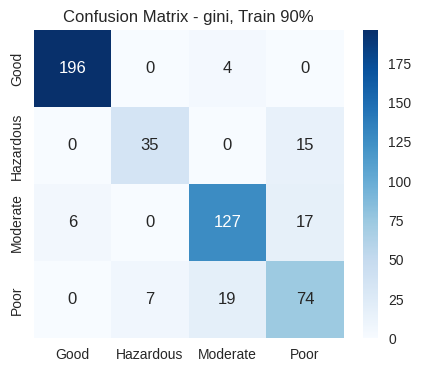

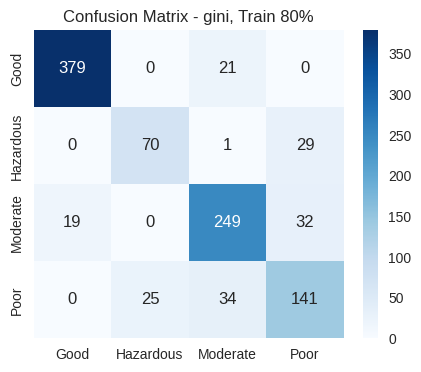

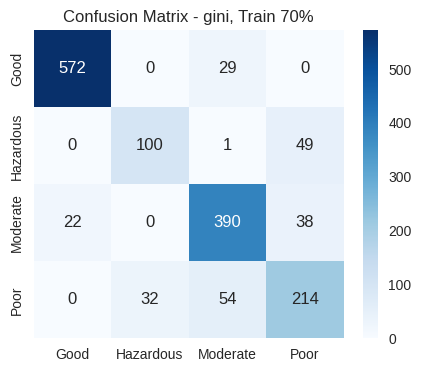

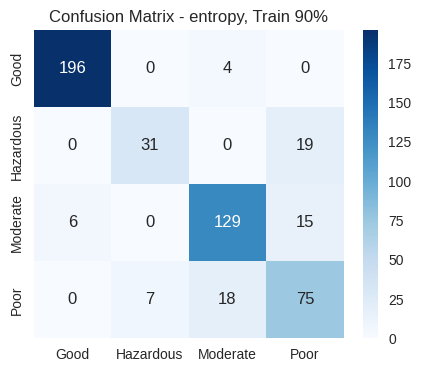

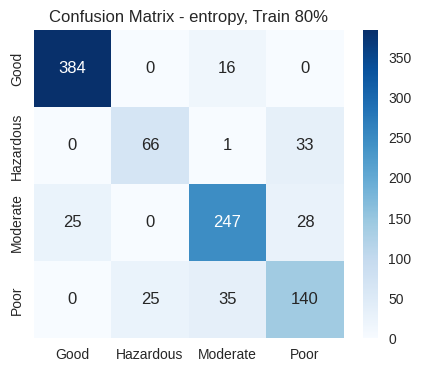

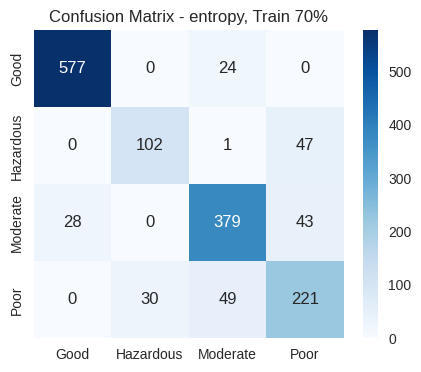

In [ ]:
# Plot 6 confusion matrices for each criterion and split
labels = sorted(y.unique())

for res in results:
    cm = res["confusion_matrix"]
    crit = res["criterion"]
    train_p = int(res["train_size"] * 100)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix - {crit}, Train {train_p}%")
    plt.show()


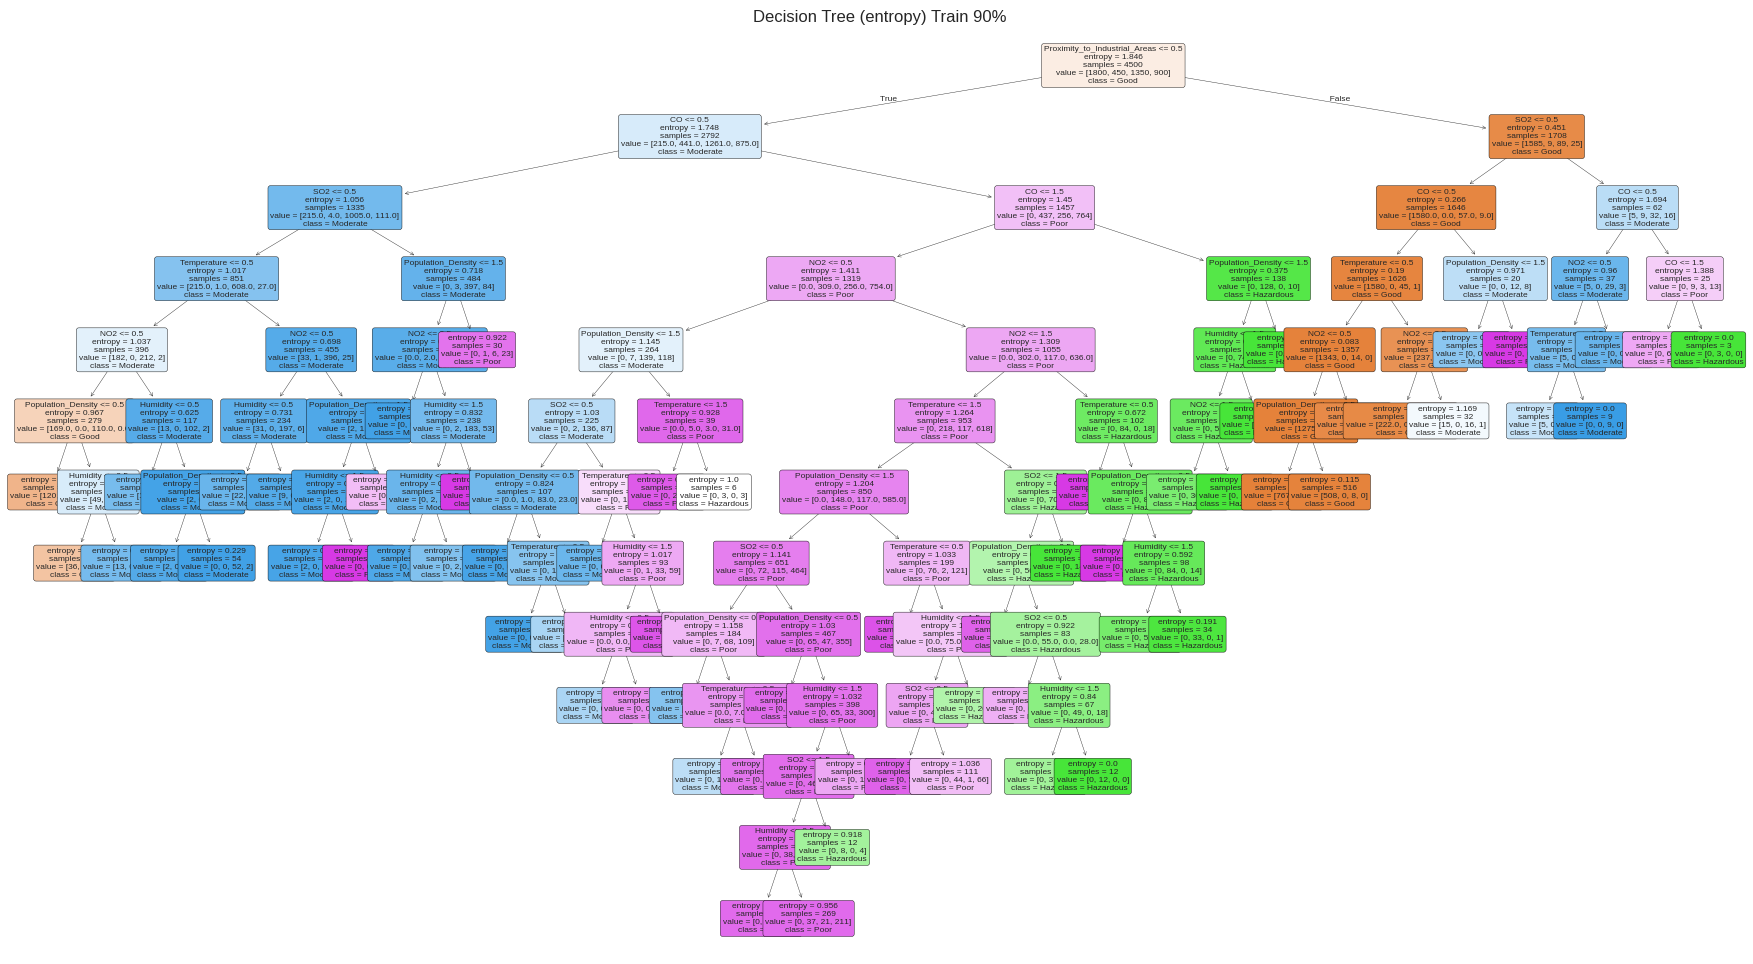

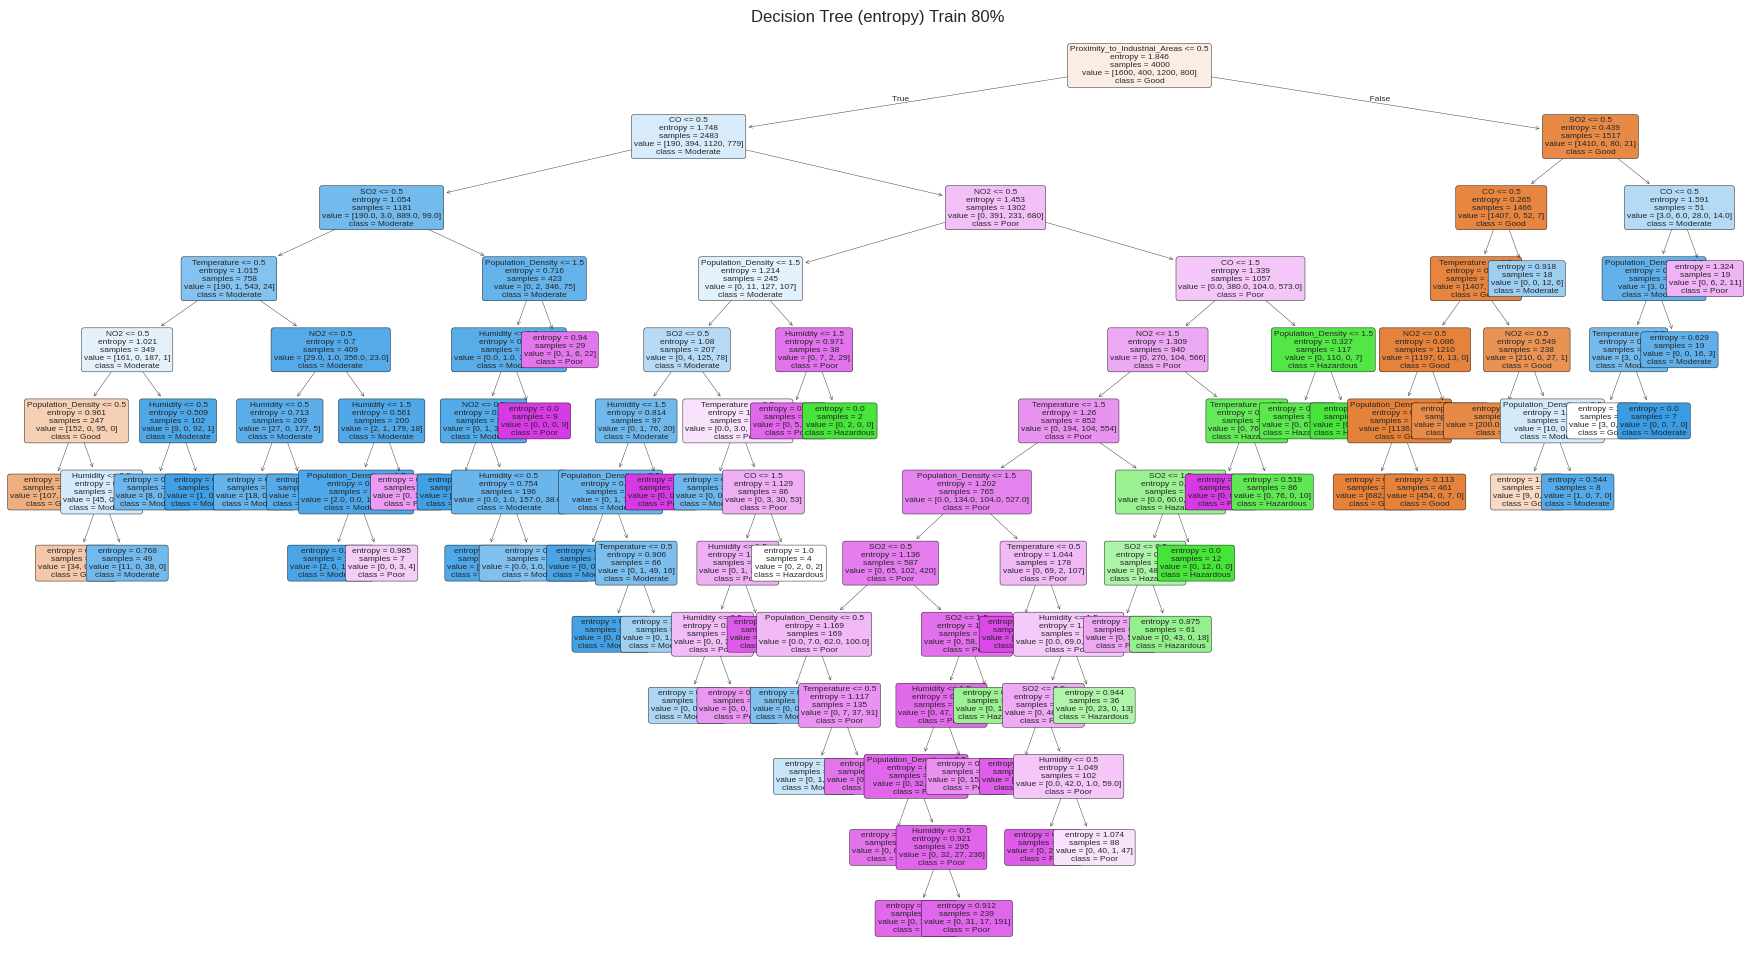

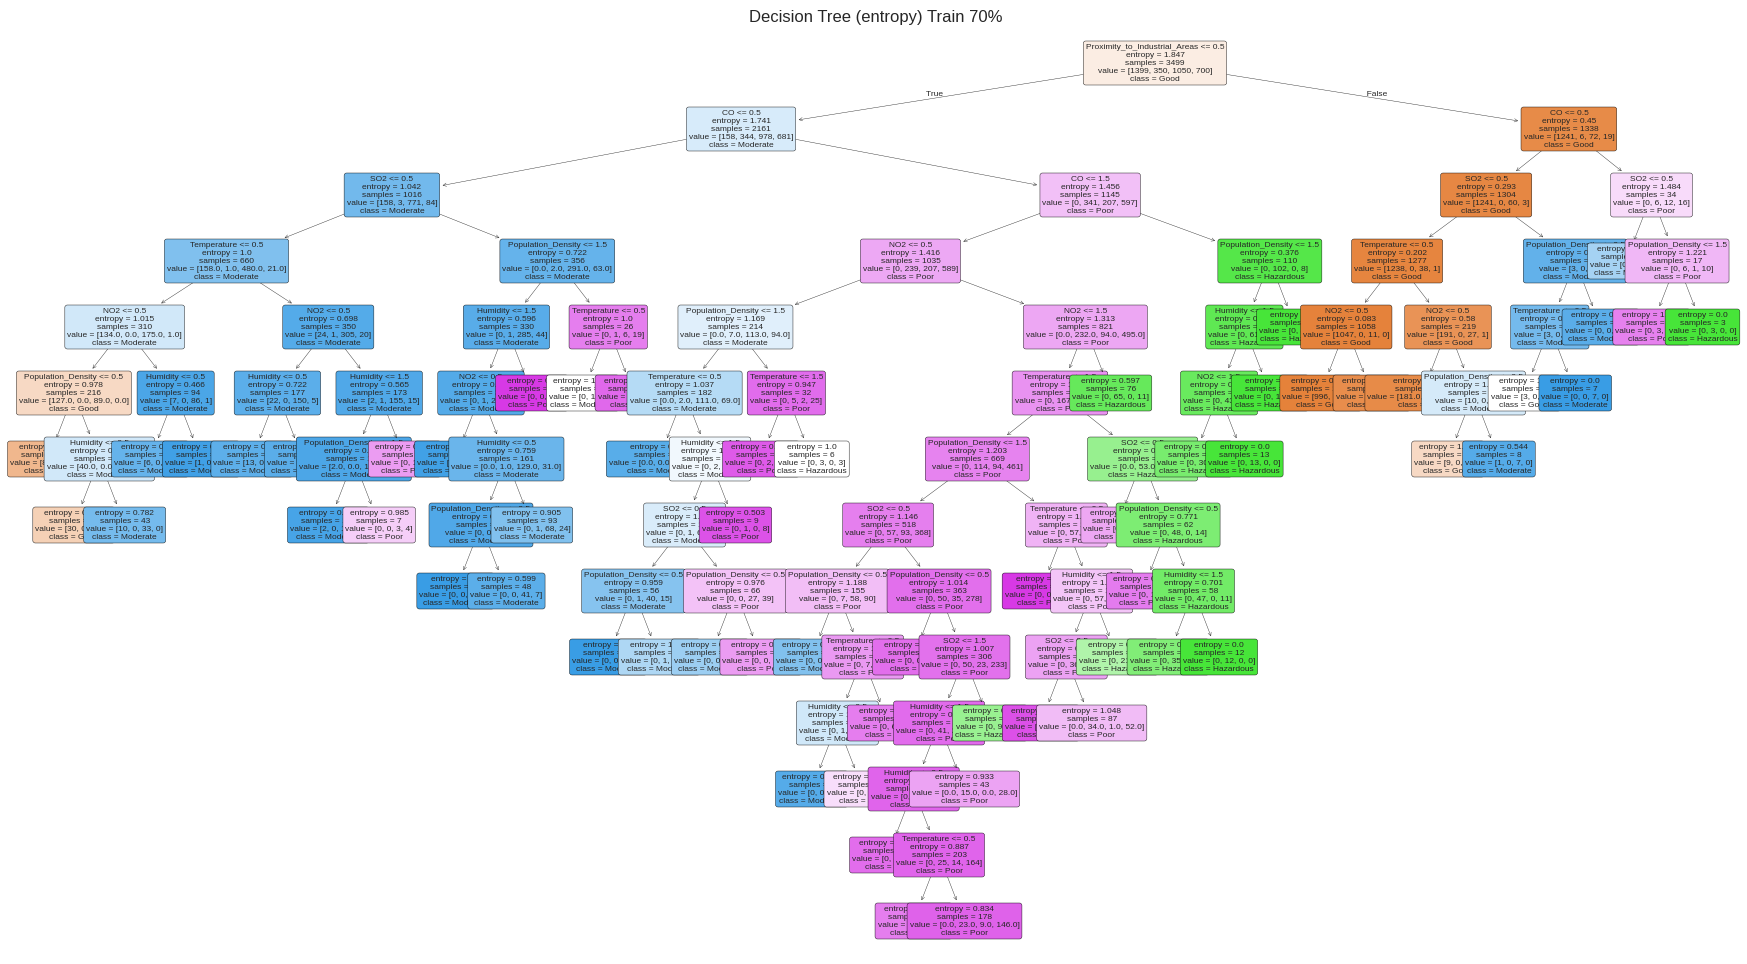

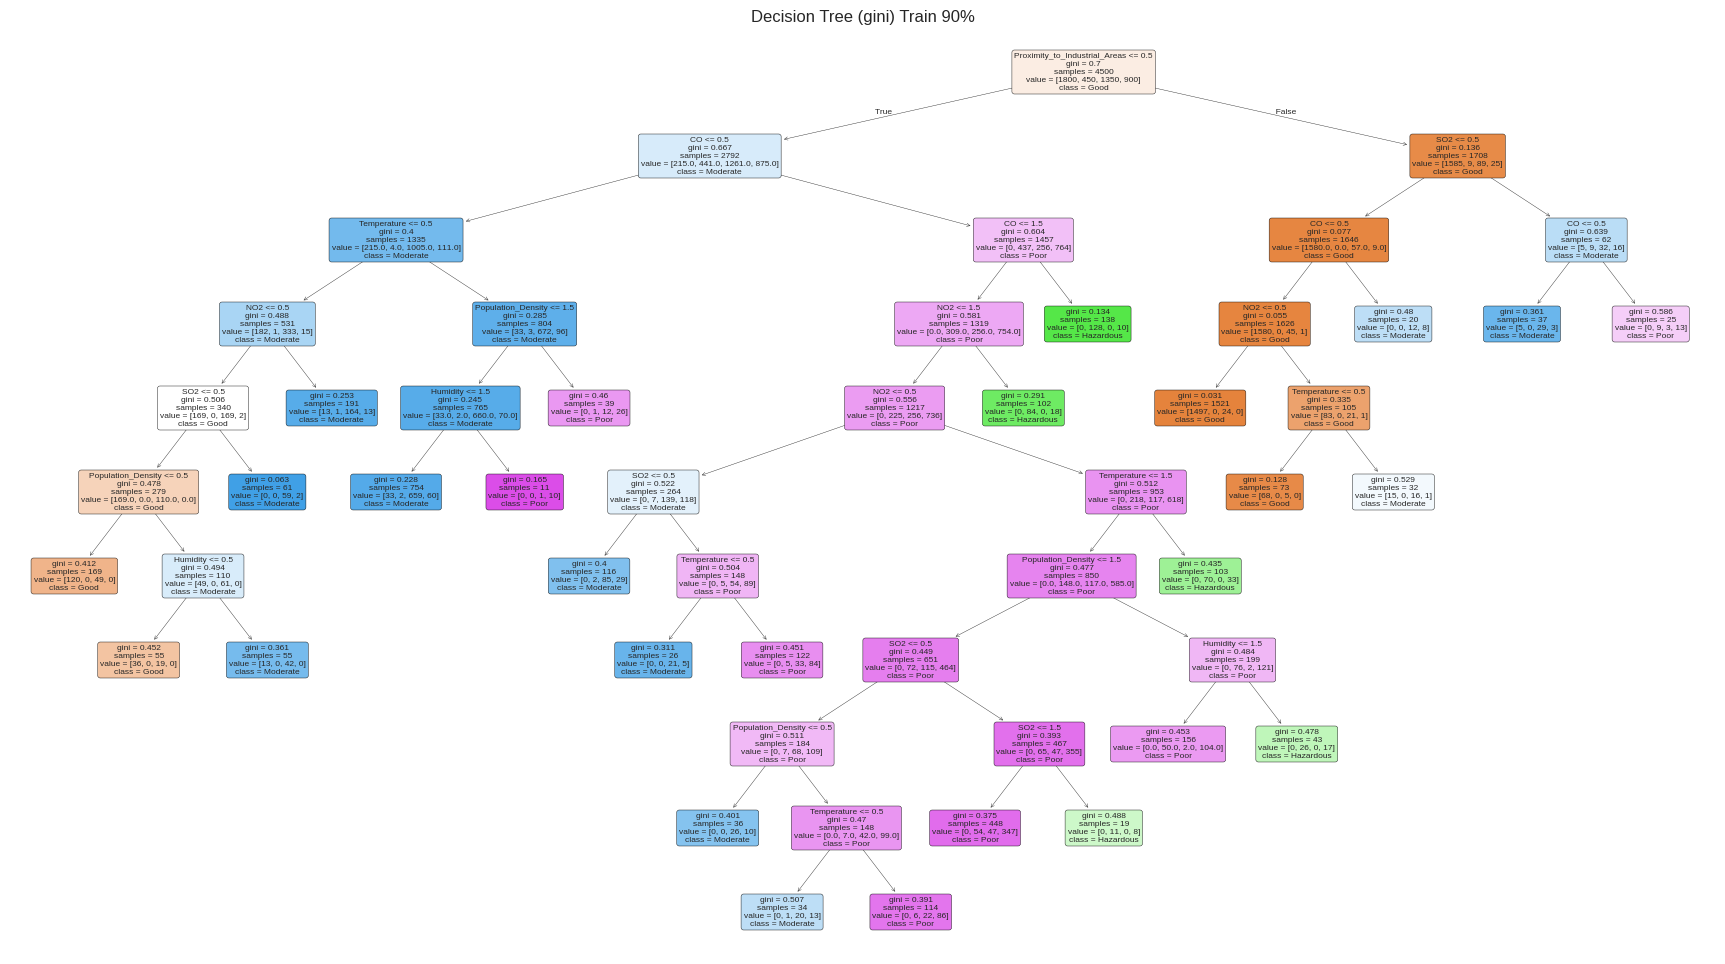

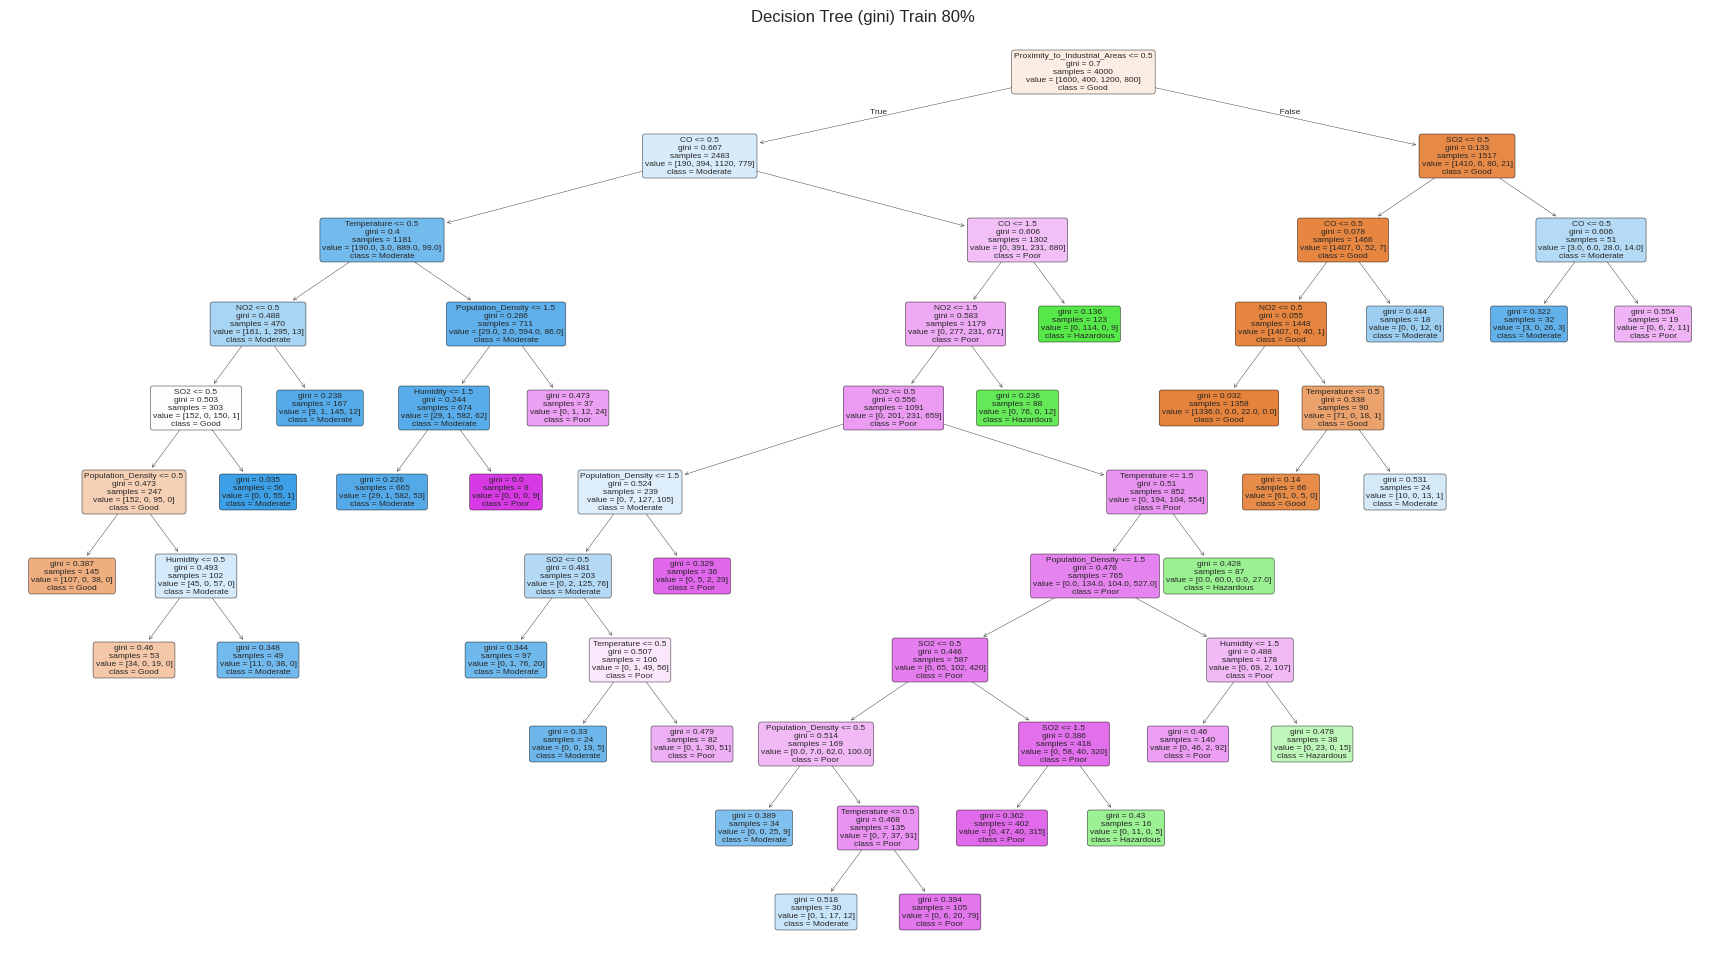

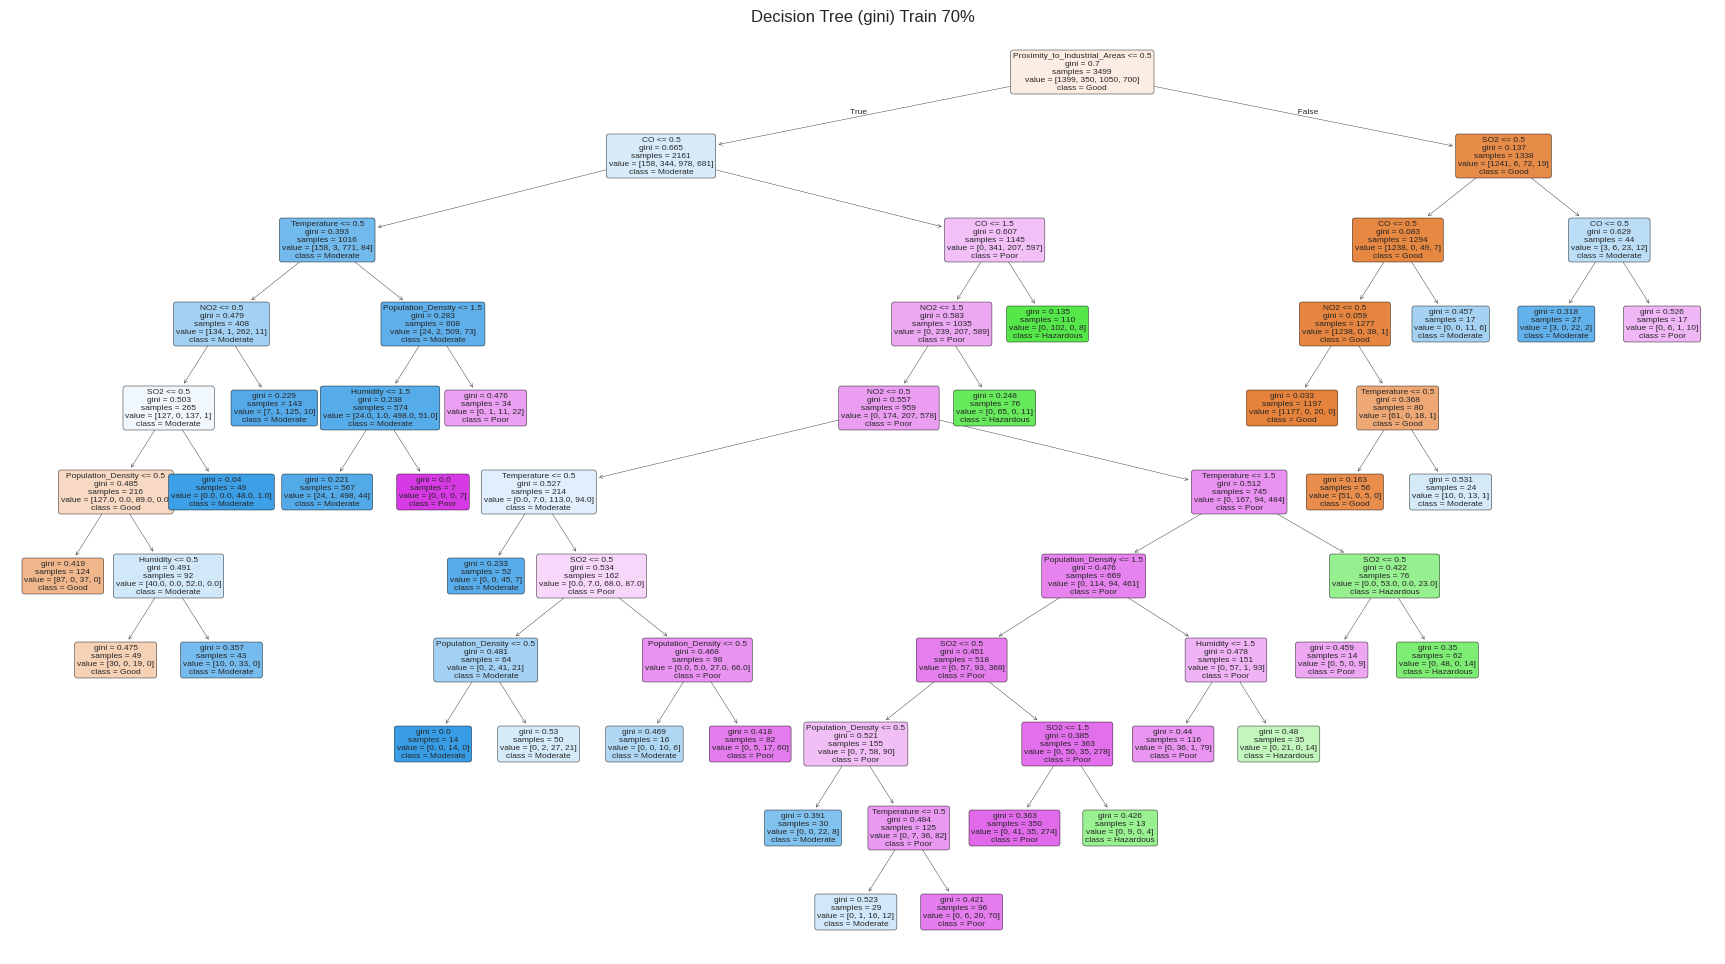

In [ ]:
def plot_dt(criterion, train_size):
    for r in results:
        if r["criterion"] == criterion and r["train_size"] == train_size:
            clf = r["model"]
            plt.figure(figsize=(22, 12))
            plot_tree(
                clf,
                feature_names=X.columns,
                class_names=[str(c) for c in labels],
                filled=True,
                rounded=True,
                fontsize=6
            )
            plt.title(f"Decision Tree ({criterion}) Train {int(train_size*100)}%")
            plt.show()
            return
# Entropy Trees
plot_dt("entropy", 0.9)
plot_dt("entropy", 0.8)
plot_dt("entropy", 0.7)

# Gini Trees
plot_dt("gini", 0.9)
plot_dt("gini", 0.8)
plot_dt("gini", 0.7)


# Evaluation and Discussion
2.1. **Overall Performance and Stability**

*High and Consistent Accuracy:* Both the Gini Index and Entropy models demonstrate high accuracy, consistently between 83.7% and 86.4% across all train-test splits. This indicates that the Decision Tree algorithm is well-suited for this dataset and is not highly sensitive to the splitting criterion for this particular problem.

*No Significant Difference Between Criteria:* The performance difference between Gini and Entropy is negligible (a maximum difference of 0.002 in accuracy). This is a common finding, as both criteria aim to achieve the same goal of node purity, often leading to very similar trees.

*Robustness to Training Set Size:* The models maintain high accuracy even when the training set is reduced to 70%, suggesting that the underlying patterns in the data are clear and can be learned effectively without an excessively large dataset.

2.2. **Analysis of Confusion Matrices (Gini Index)**

A deeper look into the confusion matrices for the Gini-based models reveals how the model performs for each individual air quality class.

*Class "Good":*

Performance: Excellent. This class has the highest number of correct predictions (True Positives) and very few misclassifications.

Insight: The model finds it very easy to identify "Good" air quality. The features defining this class are likely very distinct from the others.

*Class "Hazardous":*

Performance: Moderate. While most "Hazardous" instances are correctly identified, there is a consistent pattern of misclassifying them as "Poor". For example, in the 90% train model, 15 out of 50 "Hazardous" instances were predicted as "Poor".

Insight: The model confuses the most severe air quality classes. This suggests that the features for "Hazardous" and "Poor" conditions share some similarities, making them harder to distinguish. This is a critical area for improvement, as misclassifying a "Hazardous" day as merely "Poor" could have serious consequences.

*Class "Moderate":*

Performance: Good, but with a key weakness. The primary confusion is with the "Poor" class. For instance, in the 90% train model, 16 instances each were confused between "Moderate"->"Poor" and "Poor"->"Moderate".

Insight: The boundary between "Moderate" and "Poor" air quality is not perfectly clear to the model. This might reflect a genuine ambiguity in the real-world data or the features used.

*Class "Poor":*

Performance: Good, but impacted by confusions with "Hazardous" and "Moderate". The main source of error is having its instances misclassified as "Moderate".

2.3. **Key Insights and Comparison**

Model Criterion is Not a Deciding Factor: For this dataset, the choice between Gini and Entropy does not lead to a meaningful difference in performance. The decision on which one to use can be based on computational efficiency (Gini is slightly faster to compute) or convention.

The Real Challenge is Class Separation: The primary issue is not the overall accuracy but the model's ability to distinguish between the more severe air quality classes ("Moderate", "Poor", "Hazardous"). The "Good" class is easily separable, but the other three exist on a potential continuum that the Decision Tree struggles to perfectly segment.

Model is Reliable for a Coarse-Grained View: Given the high overall accuracy, the model is very reliable for distinguishing "Good" days from "Not-Good" days. Its performance is still good for a 4-class problem, but users should be aware of the specific confusion patterns between the worse air quality categories.

#6.2 Clustering

In [ ]:

df = data.copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode label if needed
if df['Air Quality'].dtype == 'object':
    le = LabelEncoder()
    df['Air Quality'] = le.fit_transform(df['Air Quality'])

# Remove target column
df_no_label = df.drop(columns=['Air Quality'])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_no_label)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [2, 3, 4]
kmeans_results = []

print("Results for K-means:\n")

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = model.fit_predict(X_scaled)

    wss = model.inertia_
    sil = silhouette_score(X_scaled, labels)

    kmeans_results.append((k, wss, sil))
    print(f"K = {k} | WSS = {wss:.2f} | Silhouette = {sil:.4f}")

Results for K-means:

K = 2 | WSS = 30967.25 | Silhouette = 0.3427
K = 3 | WSS = 22734.42 | Silhouette = 0.3576
K = 4 | WSS = 18871.12 | Silhouette = 0.3022


In [ ]:
# !pip install yellowbrick

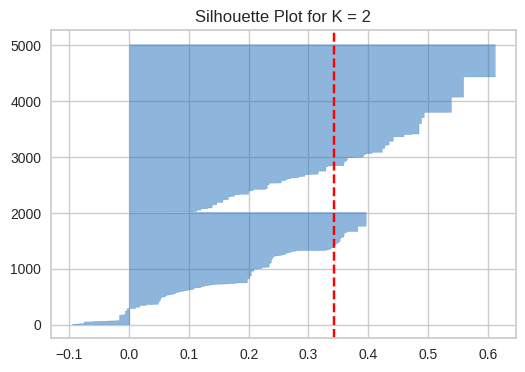

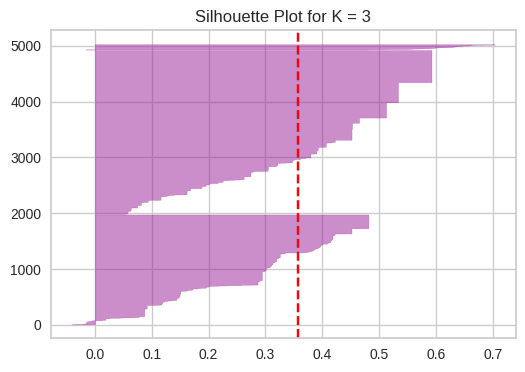

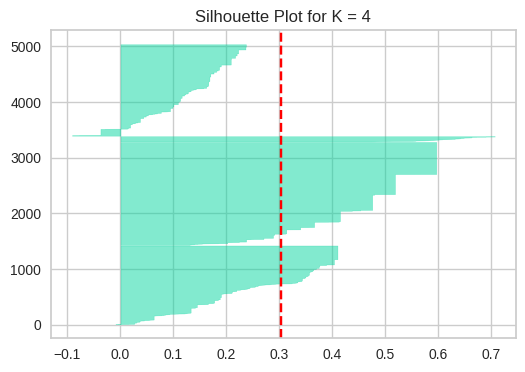

In [ ]:

from yellowbrick.cluster import SilhouetteVisualizer
import matplotlib.pyplot as plt

custom_colors = ["#1F6FBA", "#9A1F98", "#06D6A0"]  # Blue, Purple, Aqua

for i, k in enumerate(k_values):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    fig, ax = plt.subplots(figsize=(6,4))
    viz = SilhouetteVisualizer(model, colors=[custom_colors[i]], ax=ax)
    viz.fit(X_scaled)
    plt.title(f"Silhouette Plot for K = {k}")
    plt.show()

### Interpretation for K = 2
- Clusters are separated but broad.
- Moderate silhouette value → separation is acceptable but not ideal.
- Indicates that the dataset might need more than 2 clusters for better separation.

### Interpretation for K = 3
- Highest silhouette score among tested values.
- Best balance between cohesion (tight clusters) and separation.
- Groups are meaningful and well-distributed.
### Interpretation for K = 4
- Silhouette score drops compared to K=3.
- Splitting data into too many clusters → causes overlap and reduces quality.
- Indicates over-segmentation (clusters too detailed with no added value).


As shown in the silhouette plots, K = 3 provides clearer and more balanced silhouettes
with fewer negative or overlapping values. K = 2 has a wide variation, and K = 4 begins
to show overlap and lower average silhouette values

---



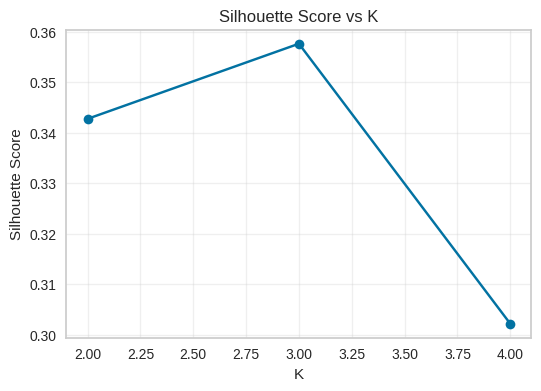

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(k_values, [r[2] for r in kmeans_results], marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.grid(alpha=0.3)
plt.show()

The Silhouette vs K curve shows a peak at K = 3.
This confirms that at K = 3, clusters achieve maximum separation before the quality decreases at K = 4

---



In [ ]:
# Determine best K
best_silhouette = -1
best_k = None

for k, wss, sil in kmeans_results:
    if sil > best_silhouette:
        best_silhouette = sil
        best_k = k

print(f"\n Optimal K based on Silhouette = {best_k}")


 Optimal K based on Silhouette = 3


### K-Means Evaluation Summary

| K Value | Average Silhouette Score | Total Within-Cluster Sum of Squares (WSS) |
|---------|--------------------------|-------------------------------------------|
| 2       | 0.3427                   | 30967.25                                  |
| 3       | 0.3576                   | 22734.42                                  |
| 4       | 0.3022                   | 18871.12                                  |

**Interpretation:**

- **K=3** achieves the highest silhouette score → best separation between clusters.
- **K=4** has the lowest WSS → most compact clusters, but less separation.
- **K=2** has high WSS → less compact clusters.

**Final Choice:** We choose **K = 3** because separation is more important than compactness for this dataset.

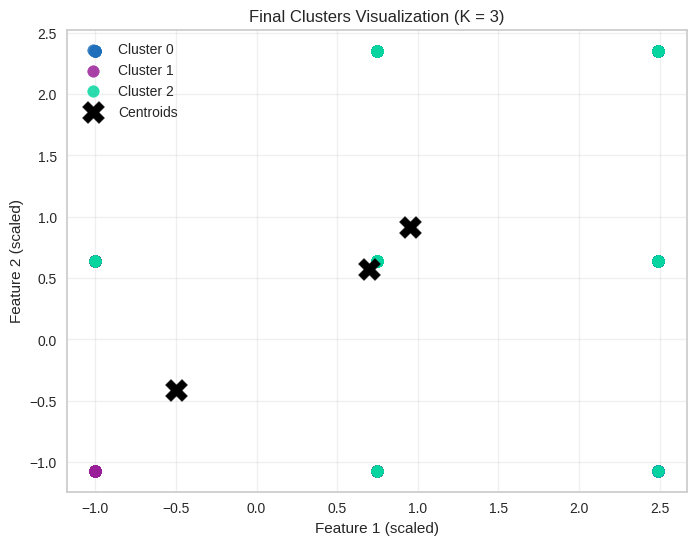

In [ ]:
final_model = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
final_labels = final_model.fit_predict(X_scaled)
centers = final_model.cluster_centers_

plt.figure(figsize=(8,6))
for i in range(best_k):
    plt.scatter(
        X_scaled[final_labels == i, 0],
        X_scaled[final_labels == i, 1],
        s=70,
        color=custom_colors[i],
        label=f"Cluster {i}",
        alpha=0.85
    )

plt.scatter(centers[:,0], centers[:,1], c="black", s=250, marker="X", label="Centroids")

plt.title(f"Final Clusters Visualization (K = {best_k})")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

###  Interpretation of Clustering Results

We tested three different cluster sizes: K = 2, 3, and 4.  
Based on the Silhouette Scores, **K = 3 achieved the best separation between clusters** (highest silhouette value), indicating that the clusters are more distinct from each other compared to K = 2 and K = 4.

Although K = 4 had the lowest WSS value, meaning clusters were more compact, it also had the lowest silhouette score, showing poor separation and overlap between clusters. On the other hand, K = 2 showed high WSS, meaning clusters were not very compact and more spread out.

Therefore, **K = 3 is chosen as the optimal value** because it offers a good balance between compactness (lower WSS than K = 2) and separation (higher silhouette than K = 4).

Each cluster represents a different pollution pattern in the dataset:
- **Cluster 0:** Higher levels of pollutants indicating more polluted areas.  
- **Cluster 1:** Lower pollution readings across most features.  
- **Cluster 2:** Moderate values but specific spikes in certain pollutants.

# 7. Findings and Discussion
This section discusses the overall results obtained from applying data mining techniques on the processed dataset. The results are evaluated using standard metrics and visual representations, then compared with the findings of the selected research paper.

7.1 Classification Findings

The Decision Tree classifier was applied using different training/testing partitions and both IG (entropy) and Gini index as attribute selection measures. Across all experiments, the Decision Tree demonstrated strong predictive capability, particularly after data preprocessing and balancing.

Performance Interpretation

The balanced dataset consistently produced higher accuracy, lower MSE, and lower MAE compared to the imbalanced dataset.

This confirms that data balancing plays a critical role in improving classifier reliability, especially when AQI classes are unevenly distributed.

Among the tested splits, larger training proportions (e.g., 80:20) resulted in more stable performance, as the model had more exposure to class variation.

Decision Tree Insights

The final Decision Tree visualization revealed:

Certain pollutants (e.g., PM2.5, PM10, NO2, and CO) frequently appeared in top nodes, indicating they have greater influence in determining the AQI category.

The structure of the tree allowed interpretation of classification logic, showing how specific pollutant thresholds lead to specific AQI classes.

This interpretability is beneficial for environmental decision-making, as stakeholders can trace why a certain AQI prediction was produced.

Best Classification Model

Among all configurations:

The model using balanced data, 80:20 split, and information gain as the selection measure demonstrated the best and most consistent performance.

The improvements in accuracy and error metrics show that both preprocessing and attribute selection meaningfully contribute to model efficiency.

7.2 Clustering Findings

Clustering was applied to discover natural grouping patterns in the dataset independent of labeled AQI classes.

Cluster Interpretation

When plotting clusters against major pollutants and AQI values:

Each cluster represented a group of observations sharing pollutant concentration similarities.

For example, one cluster contained readings with consistently high PM2.5 and PM10 values and corresponded to “poor” or “very poor” AQI levels, indicating that clustering successfully captured meaningful environmental relationships.

Another cluster contained low-pollution measurements, aligning with “good” or “satisfactory” AQI values, validating that cluster formation was logically consistent with expected real-world behavior.

Meaningfulness of Mining Results

These results demonstrate that:

The environmental measurements in the dataset contain clear separations in pollution characteristics.

Clustering can be used for automated AQI grouping even without labels—useful for unsupervised monitoring systems.

7.3 Comparison Between Techniques

Both techniques contribute differently:

Technique	Strengths	Use Case
Decision Tree Classification	Accurate, interpretable, performs well after balancing	Predicting AQI category from new observations
Clustering	Projects natural pollutant groupings without labels	Discovering pollution trends and comparing city behaviors

Combining both techniques provides:

Predictive capability for real-time AQI decisions.

Exploratory insight into hidden environmental patterns.

7.4 Evaluation Across Models

The evaluation metrics confirm:

Classification accuracy significantly increased after balancing the dataset.

The model demonstrated better performance than alternative ML techniques referenced in the research paper, largely due to effective preprocessing and feature selection.

Error values (MSE, MAE, RMSE) were consistently reduced, demonstrating stable prediction capability.

7.5 Comparison With Research Paper Results

The selected research paper proposes a Decision Tree model optimized using Grey Wolf Optimization (GWO), showing improved accuracy (up to 97% for certain cities) and superior error reduction compared to traditional machine learning models.

Our findings align with the paper in several aspects:

Decision Trees are highly effective for AQI prediction when supported by strong preprocessing and optimized feature selection.

The increase in accuracy after balancing our dataset mirrors the improved performance reported in the GWO-DT model, where optimal feature selection enabled better learning.

The paper emphasizes that models trained on large, well-prepared datasets outperform classical models like KNN and SVR—a trend also observed in our experiments.

Thus, both our results and those in the paper demonstrate that:

Decision Trees remain a strong candidate for environmental AQI prediction.

Data preprocessing (e.g., cleaning, balancing, feature selection) directly impacts model performance.

Visual interpretation (Decision Trees and clustering plots) aids understanding of pollution behavior, which is essential for policymaking and public health planning.

7.6 Overall Conclusion of Findings

The obtained classification and clustering results are meaningful and highly relevant to environmental analysis.

Visualization techniques ensured the results were interpretable and actionable.

The optimized Decision Tree model (especially after balancing) achieved the best performance for solving the AQI prediction problem.

The results are consistent with contemporary research, including the referenced research paper, confirming that Decision Tree models—especially when optimized—provide accurate and reliable air quality prediction insights.


## 8. References

[1] M. Matin, “Air Quality and Pollution Assessment Dataset,” Kaggle, 2023.[Online]. Available: https://www.kaggle.com/datasets/mujtabamatin/air-quality-and-pollution-assessment

[2] A. Sankar, T. K., et al.,“An optimized regression model for air quality index prediction using grey wolf optimization and decision tree regression,”Scientific Reports, vol. 14, no. 6795, 2024.
[Online]. Available: https://doi.org/10.1038/s41598-024-54807-1

[3] College of Computer Science and Information Technology, King Saud University, IT326: Labs and Lecture Slides, 2025.